# CardioIA Fase 4 - Ir Alem 1: Etica e Fairness em Visao Computacional

**FIAP | Tecnologo em Inteligencia Artificial | Fase 4 | Capitulo 1 | Grupo 72**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juanvoltolini-rm562890/CardioIA-Fase4-Cap1/blob/main/notebooks/04_fairness.ipynb)

Analise de **vieses do dataset e do modelo**. O modelo auditado e o **VGG16 (Transfer Learning, NB03)** da Pessoa 3, baixado do Google Drive.

Roteiro:
1. Limitacoes do dataset (pediatrico, fonte unica, sem metadados demograficos, desbalanceamento).
2. Desempenho **no conjunto de teste (624)** - o NB03 reportou metricas so na validacao; aqui fechamos isso.
3. Fairness por subgrupo clinico (pneumonia **bacteriana vs viral**): sensibilidade, FNR e disparidade (equal opportunity).
4. Proxies tecnicos: desempenho por **brilho** e **resolucao** da imagem.
5. **Calibracao** do modelo (curva de confiabilidade + Brier score).

> O VGG16 foi treinado com normalizacao `rescale = 1/255` (nao `preprocess_input`); usamos **a mesma** aqui para reproduzir fielmente as predicoes. Rotulo: **NORMAL = 0, PNEUMONIA = 1**.

## 1. Configuracao do ambiente

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from PIL import Image
from IPython.display import display

SEED = 42
keras.utils.set_random_seed(SEED)

IMG = 224
BATCH = 32
AUTOTUNE = tf.data.AUTOTUNE
MAPA_ROTULO = {'NORMAL': 0, 'PNEUMONIA': 1}

print('TensorFlow:', tf.__version__)
print('GPU disponivel:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU disponivel: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Manifesto do conjunto de teste

A analise de fairness roda **no conjunto de teste** (`test.csv`, 624 imagens), que ficou intocado no treino. Lemos do GitHub publico com fallback automatico para `files.upload()`.

In [2]:
BASE_SPLITS = 'https://raw.githubusercontent.com/juanvoltolini-rm562890/CardioIA-Fase4-Cap1/main/data/splits'

try:
    test_df = pd.read_csv(BASE_SPLITS + '/test.csv')
    print('test.csv carregado do GitHub.')
except Exception as e:
    print('Falha ao ler do GitHub (' + str(e)[:80] + '). Envie test.csv de data/splits/:')
    from google.colab import files
    import io
    up = files.upload()
    test_df = pd.read_csv(io.BytesIO(up['test.csv']))

print('Total de teste:', len(test_df))
print('Por classe:', test_df.label.value_counts().to_dict())
print('Por subtipo:', test_df.subtipo.value_counts().to_dict())

test.csv carregado do GitHub.
Total de teste: 624
Por classe: {'PNEUMONIA': 390, 'NORMAL': 234}
Por subtipo: {'bacteria': 242, 'normal': 234, 'virus': 148}


## 3. Download do dataset (imagens)

Baixamos o dataset via `kagglehub` e localizamos a raiz com `train/`, `val/` e `test/` (ignorando duplicatas e `__MACOSX`). Os `filepath` do CSV sao relativos a essa raiz.

In [3]:
import kagglehub
from pathlib import Path

download_root = Path(kagglehub.dataset_download('paultimothymooney/chest-xray-pneumonia'))

def localizar_raiz_dataset(base):
    candidatos = []
    for dirpath, dirnames, _ in os.walk(base):
        p = Path(dirpath)
        if '__MACOSX' in p.parts:
            continue
        if {'train', 'val', 'test'}.issubset(set(dirnames)):
            candidatos.append(p)
    if not candidatos:
        raise FileNotFoundError('Nao encontrei train/val/test abaixo de ' + str(base))
    return sorted(candidatos, key=lambda p: len(p.parts))[0]

DATA_ROOT = localizar_raiz_dataset(download_root)
print('Raiz do dataset:', DATA_ROOT)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Raiz do dataset: /kaggle/input/chest-xray-pneumonia/chest_xray


## 4. Download do modelo VGG16 (Google Drive)

O `.keras` nao esta no git; baixamos do Google Drive (link no README, publicado pela Pessoa 3). Se o `gdown` falhar (link restrito), a celula pede o upload manual do arquivo.

In [4]:
!pip install -q gdown
import gdown

VGG16_DRIVE_ID = '1cnCgAeOt1tJvHRd85B_rONsZQ5TFG6En'  # id do link do README
try:
    gdown.download(id=VGG16_DRIVE_ID, output='vgg16_finetuned.keras', quiet=False)
    assert os.path.exists('vgg16_finetuned.keras')
except Exception as e:
    print('Falha no gdown (' + str(e)[:80] + '). Envie vgg16_finetuned.keras manualmente:')
    from google.colab import files
    files.upload()

modelo_vgg = keras.models.load_model('vgg16_finetuned.keras')
print('VGG16 carregado | entrada:', modelo_vgg.input_shape, '| saida:', modelo_vgg.output_shape)

Downloading...
From (original): https://drive.google.com/uc?id=1cnCgAeOt1tJvHRd85B_rONsZQ5TFG6En
From (redirected): https://drive.google.com/uc?id=1cnCgAeOt1tJvHRd85B_rONsZQ5TFG6En&confirm=t&uuid=c28d7c2a-0070-4bc2-9e8e-321b4a0516bf
To: /content/vgg16_finetuned.keras
100%|██████████| 60.5M/60.5M [00:01<00:00, 38.3MB/s]


VGG16 carregado | entrada: (None, 224, 224, 3) | saida: (None, 1)


## 5. Predicoes no teste e proxies por imagem

Pipeline de inferencia identico ao treino do VGG16: resize 224x224, RGB e **`/255`** (o VGG16 do NB03 nao tem camada de normalizacao embutida). Para cada imagem calculamos tambem dois **proxies tecnicos**: brilho medio e resolucao original (na falta de metadados demograficos).

In [5]:
def carregar_vgg(caminho, rotulo):
    img = tf.io.read_file(caminho)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, [IMG, IMG])
    img = img / 255.0                      # mesma normalizacao do treino do VGG16 (rescale=1/255)
    return img, rotulo

caminhos = [str(DATA_ROOT / fp) for fp in test_df.filepath]
rotulos = test_df.label.map(MAPA_ROTULO).astype('float32').values

ds = (tf.data.Dataset.from_tensor_slices((caminhos, rotulos))
      .map(carregar_vgg, num_parallel_calls=AUTOTUNE)
      .batch(BATCH).prefetch(AUTOTUNE))

y_true = test_df.label.map(MAPA_ROTULO).values.astype(int)
y_prob = modelo_vgg.predict(ds, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)
print('Predicoes:', y_prob.shape, '| prob media:', round(float(y_prob.mean()), 3))

Predicoes: (624,) | prob media: 0.738


In [6]:
brilhos, larguras, alturas = [], [], []
for fp in test_df.filepath:
    with Image.open(DATA_ROOT / fp) as im:
        larguras.append(im.size[0])
        alturas.append(im.size[1])
        brilhos.append(float(np.asarray(im.convert('L')).mean()))

res = pd.DataFrame({
    'subtipo': test_df.subtipo.values,
    'y_true': y_true,
    'y_prob': y_prob,
    'y_pred': y_pred,
    'brilho': brilhos,
    'resolucao': np.array(larguras) * np.array(alturas),
})
display(res.head())

,subtipo,y_true,y_prob,y_pred,brilho,resolucao
0,normal,0,0.311454,0,130.998608,2445669
1,normal,0,0.319930,0,142.445303,3185499
2,normal,0,0.248180,0,136.249559,3730947
3,normal,0,0.470867,0,148.670080,2205138
4,normal,0,0.085471,0,137.699779,3732354


## 6. Desempenho global no conjunto de teste

Antes do recorte por subgrupo, o desempenho agregado **no teste** - a metrica que faltava no NB03 (que avaliou apenas na validacao).

              precision    recall  f1-score   support

      NORMAL      0.936     0.624     0.749       234
   PNEUMONIA      0.812     0.974     0.886       390

    accuracy                          0.843       624
   macro avg      0.874     0.799     0.817       624
weighted avg      0.858     0.843     0.834       624

AUC-ROC (teste): 0.9378


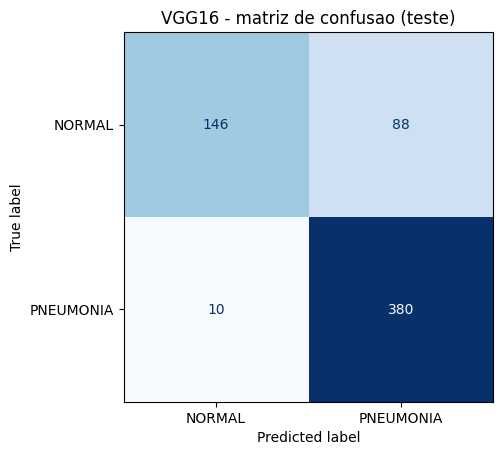

In [7]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score)

print(classification_report(y_true, y_pred, target_names=['NORMAL', 'PNEUMONIA'], digits=3))
print('AUC-ROC (teste):', round(roc_auc_score(y_true, y_prob), 4))

cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['NORMAL', 'PNEUMONIA']).plot(cmap='Blues', colorbar=False)
plt.title('VGG16 - matriz de confusao (teste)')
plt.savefig('fairness_matriz_teste.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Limitacoes do dataset

- **Populacao pediatrica (1-5 anos) de um unico hospital** (Guangzhou Women and Children's Medical Center): nada garante generalizacao para adultos, idosos, outros equipamentos ou protocolos de aquisicao.
- **Ausencia de metadados demograficos** (sexo, etnia, idade exata): impossivel auditar fairness por esses eixos sensiveis - uma limitacao etica que declaramos explicitamente, em vez de simular grupos inexistentes.
- **Desbalanceamento (~73% pneumonia)**: a acuracia global engana; por isso o foco e em metricas por subgrupo e por classe.
- **Unico subgrupo clinico auditavel**: a particao **bacteriana vs viral** (extraida do nome do arquivo) e o eixo principal de fairness; os proxies tecnicos (brilho, resolucao) complementam.

## 8. Fairness por subgrupo clinico (bacteriana vs viral)

Criterio de **igualdade de oportunidade** (equal opportunity): o modelo deveria ter **sensibilidade** (recall) semelhante ao detectar pneumonia, independentemente do subtipo. Reportamos sensibilidade e FNR para os grupos positivos (bacteria, virus) e especificidade para o grupo negativo (normal).

In [8]:
def taxas_por_grupo(df):
    linhas = []
    for grupo, d in df.groupby('subtipo'):
        n = len(d)
        if grupo == 'normal':
            tn = int(((d.y_true == 0) & (d.y_pred == 0)).sum())
            fp = int(((d.y_true == 0) & (d.y_pred == 1)).sum())
            espec = tn / (tn + fp) if (tn + fp) else np.nan
            linhas.append({'grupo': grupo, 'n': n, 'tipo': 'negativo',
                           'sensib/especif': round(espec, 3), 'erro (FNR/FPR)': round(1 - espec, 3),
                           'conf_media': round(float(d.y_prob.mean()), 3)})
        else:
            tp = int(((d.y_true == 1) & (d.y_pred == 1)).sum())
            fn = int(((d.y_true == 1) & (d.y_pred == 0)).sum())
            sens = tp / (tp + fn) if (tp + fn) else np.nan
            linhas.append({'grupo': grupo, 'n': n, 'tipo': 'positivo',
                           'sensib/especif': round(sens, 3), 'erro (FNR/FPR)': round(1 - sens, 3),
                           'conf_media': round(float(d.y_prob.mean()), 3)})
    return pd.DataFrame(linhas)

tabela = taxas_por_grupo(res)
display(tabela)

sb = res[res.subtipo == 'bacteria']
sv = res[res.subtipo == 'virus']
rec_b = float((sb.y_pred == 1).mean())
rec_v = float((sv.y_pred == 1).mean())
print('Sensibilidade  bacteriana: %.3f | viral: %.3f' % (rec_b, rec_v))
print('Gap de equal opportunity: %.3f | razao (min/max): %.3f' % (abs(rec_b - rec_v), min(rec_b, rec_v) / max(rec_b, rec_v)))

,grupo,n,tipo,sensib/especif,erro (FNR/FPR),conf_media
0,bacteria,242,positivo,0.975,0.025,0.916
1,normal,234,negativo,0.624,0.376,0.452
2,virus,148,positivo,0.973,0.027,0.900


Sensibilidade  bacteriana: 0.975 | viral: 0.973
Gap de equal opportunity: 0.002 | razao (min/max): 0.998


## 9. Proxies tecnicos: brilho e resolucao

Sem metadados demograficos, testamos se o modelo erra mais em imagens **escuras** ou de **baixa resolucao** - fontes de vies tecnico que afetariam desproporcionalmente certos equipamentos ou unidades de saude. Dividimos o teste em tercis.

In [9]:
def metricas_por_faixa(df, coluna):
    faixas = pd.qcut(df[coluna], 3, labels=['baixo', 'medio', 'alto'])
    linhas = []
    for faixa, d in df.groupby(faixas, observed=True):
        acc = float((d.y_true == d.y_pred).mean())
        pos = d[d.y_true == 1]
        sens = float((pos.y_pred == 1).mean()) if len(pos) else np.nan
        linhas.append({'faixa': str(faixa), 'n': len(d),
                       coluna + '_medio': round(float(d[coluna].mean()), 1),
                       'acuracia': round(acc, 3), 'sensibilidade': round(sens, 3)})
    return pd.DataFrame(linhas)

print('Desempenho por faixa de BRILHO:')
display(metricas_por_faixa(res, 'brilho'))
print('Desempenho por faixa de RESOLUCAO:')
display(metricas_por_faixa(res, 'resolucao'))

Desempenho por faixa de BRILHO:


,faixa,n,brilho_medio,acuracia,sensibilidade
0,baixo,208,102.5,0.861,0.965
1,medio,208,121.1,0.885,0.977
2,alto,208,139.4,0.784,0.982


Desempenho por faixa de RESOLUCAO:


,faixa,n,resolucao_medio,acuracia,sensibilidade
0,baixo,209,628673.3,0.976,0.995
1,medio,207,1125974.3,0.836,0.975
2,alto,208,2882775.5,0.716,0.821


## 10. Calibracao do modelo

Um modelo bem calibrado tem confianca que reflete a probabilidade real (quando diz 0,8, acerta ~80% das vezes). Em saude, a calibracao importa tanto quanto a acuracia para apoiar decisao clinica. Avaliamos com a **curva de confiabilidade** e o **Brier score** (quanto menor, melhor).

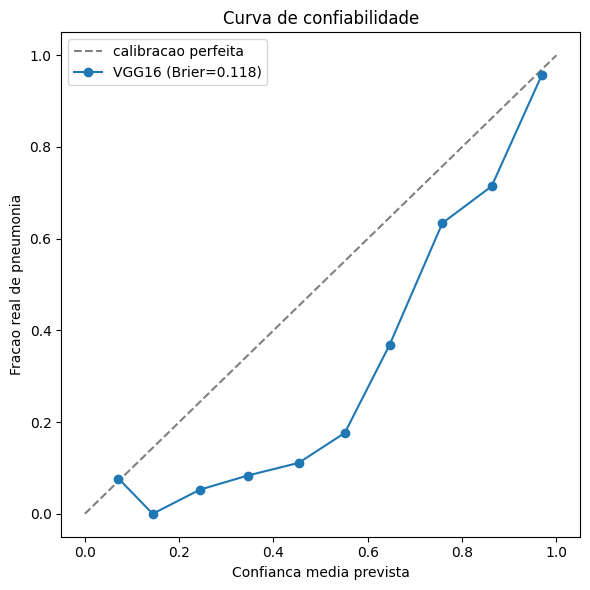

Brier score: 0.1181


In [10]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

frac_pos, media_prev = calibration_curve(y_true, y_prob, n_bins=10, strategy='uniform')
brier = brier_score_loss(y_true, y_prob)

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], '--', color='gray', label='calibracao perfeita')
plt.plot(media_prev, frac_pos, 'o-', label='VGG16 (Brier=%.3f)' % brier)
plt.xlabel('Confianca media prevista')
plt.ylabel('Fracao real de pneumonia')
plt.title('Curva de confiabilidade')
plt.legend()
plt.tight_layout()
plt.savefig('fairness_calibracao.png', dpi=120, bbox_inches='tight')
plt.show()
print('Brier score:', round(float(brier), 4))

## 11. (Opcional) Comparativo com a CNN do zero

Quando o `cnn_zero.keras` (NB02) estiver disponivel (GitHub Release `v1.0-modelos` ou upload), defina `INCLUIR_CNN = True` para comparar a disparidade bacteriana/viral dos dois modelos - mostra se o Transfer Learning aumenta ou reduz o vies entre subtipos.

Atencao: a CNN do zero tem `Rescaling(1/255)` **embutido**, entao **nao** se divide por 255 de novo.

In [12]:
INCLUIR_CNN = True  # mude para True quando tiver cnn_zero.keras

if INCLUIR_CNN:
    def carregar_cnn(caminho, rotulo):
        img = tf.io.read_file(caminho)
        img = tf.io.decode_image(img, channels=3, expand_animations=False)
        img.set_shape([None, None, 3])
        img = tf.image.resize(img, [IMG, IMG])      # SEM /255 (Rescaling embutido no modelo)
        return img, rotulo

    ds_cnn = (tf.data.Dataset.from_tensor_slices((caminhos, rotulos))
              .map(carregar_cnn, num_parallel_calls=AUTOTUNE).batch(BATCH).prefetch(AUTOTUNE))
    modelo_cnn = keras.models.load_model('cnn_zero.keras')
    prob_cnn = modelo_cnn.predict(ds_cnn, verbose=0).ravel()
    pred_cnn = (prob_cnn >= 0.5).astype(int)

    res_cnn = res.copy()
    res_cnn['y_prob'] = prob_cnn
    res_cnn['y_pred'] = pred_cnn
    sb2 = res_cnn[res_cnn.subtipo == 'bacteria']
    sv2 = res_cnn[res_cnn.subtipo == 'virus']
    print('CNN do zero - sensibilidade bacteriana: %.3f | viral: %.3f'
          % (float((sb2.y_pred == 1).mean()), float((sv2.y_pred == 1).mean())))
    print('VGG16       - sensibilidade bacteriana: %.3f | viral: %.3f' % (rec_b, rec_v))
else:
    print('Comparativo com a CNN desativado (defina INCLUIR_CNN=True quando cnn_zero.keras estiver disponivel).')

CNN do zero - sensibilidade bacteriana: 0.996 | viral: 1.000
VGG16       - sensibilidade bacteriana: 0.975 | viral: 0.973


## 12. Conclusao

- O VGG16 foi auditado **no conjunto de teste** (fechando a lacuna do NB03, que avaliou na validacao).
- A disparidade **bacteriana vs viral** (sensibilidade/FNR) quantifica o vies clinico mais relevante e auditavel deste dataset.
- Os proxies de **brilho** e **resolucao** indicam vies tecnico; a **calibracao** mostra se a confianca do modelo e confiavel para apoio a decisao.
- Principais limitacoes (populacao pediatrica, fonte unica, sem metadados demograficos) e as mitigacoes propostas estao em `docs/relatorio_ir_alem1_fairness.md`.

**Antes de commitar:** rodar no Colab (`Run all`), salvar **com outputs** e copiar `fairness_matriz_teste.png` e `fairness_calibracao.png` para `assets/evidencias/`.

In [13]:
from google.colab import files
files.download('fairness_matriz_teste.png')
files.download('fairness_calibracao.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>